<a href="https://colab.research.google.com/github/nazerke001/credit-risk-prediction/blob/main/Credit_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('credit_risk_dataset.csv')

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [8]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [10]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [11]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [12]:
df.duplicated().sum()

np.int64(165)

In [13]:
df.drop_duplicates()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.00,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.00,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.00,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.00,PERSONAL,B,15000,11.48,0,0.10,N,26


What does Loan status look like?

1.   List item
2.   List item



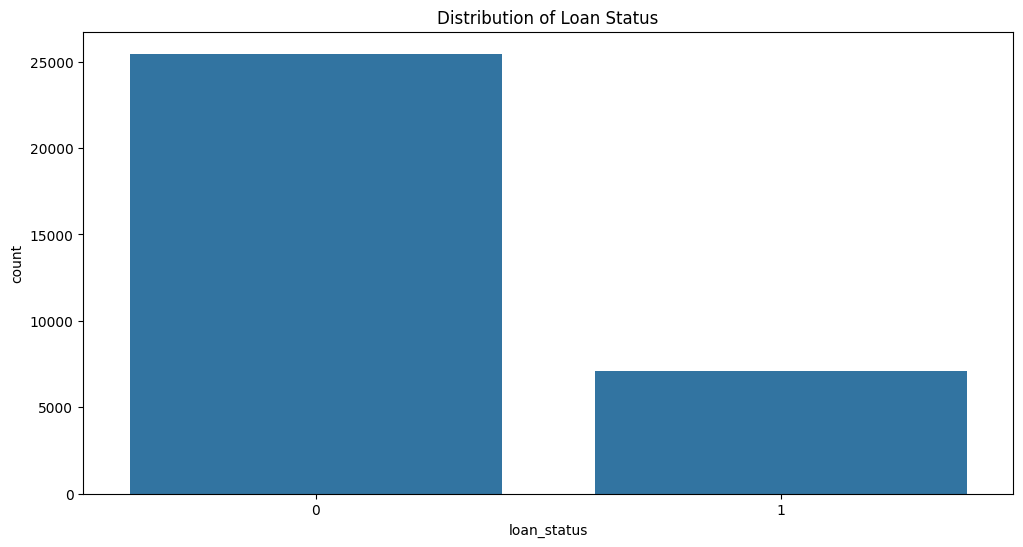

In [19]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Loan Status")
sns.countplot(x=df['loan_status'])
plt.show()

Most borrowers have loan status of 0, while fewer borrowers have a loan status of 1.Therefore, the target variable is imbalanced.

In [20]:
df['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,6453
MEDICAL,6071
VENTURE,5719
PERSONAL,5521
DEBTCONSOLIDATION,5212
HOMEIMPROVEMENT,3605


Is there a difference in annual income between borrowers who defaulted and those who did not?

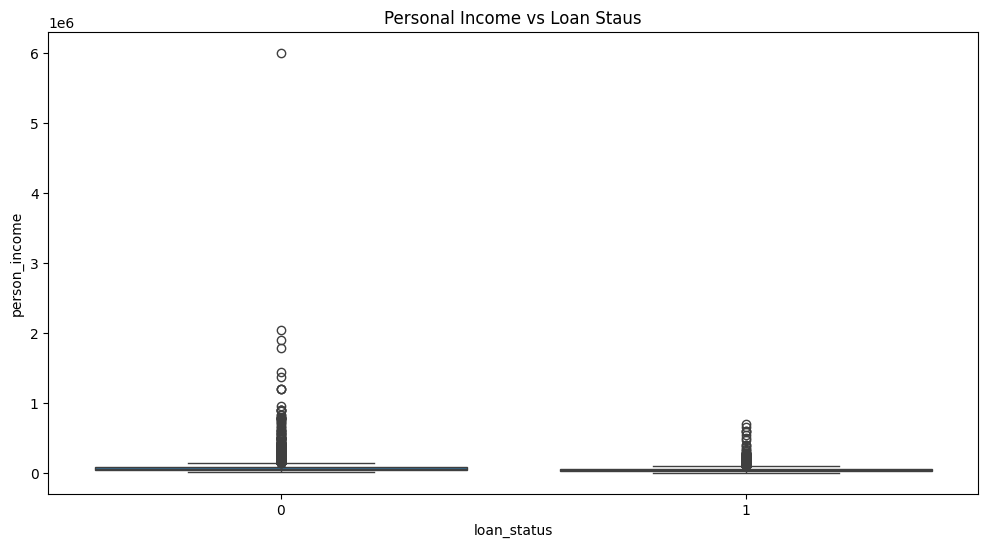

In [25]:
plt.figure(figsize=(12,6))
plt.title("Personal Income vs Loan Staus")
sns.boxplot(data=df,x='loan_status',y='person_income')
plt.show()

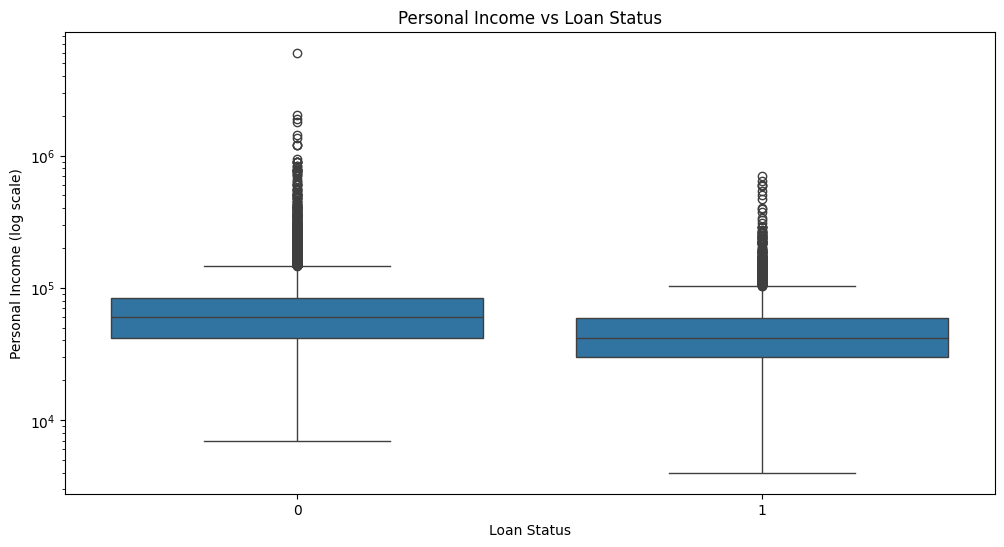

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='loan_status', y='person_income')
plt.yscale('log')
plt.title('Personal Income vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Personal Income (log scale)')

plt.show()

In [27]:
df['person_income'].describe()

,person_income
count,32581.00
mean,66074.85
std,61983.12
min,4000.00
25%,38500.00
50%,55000.00
75%,79200.00
max,6000000.00


In [28]:
df['person_income'].sort_values(ascending=False).head(10)

,person_income
32297,6000000
30049,2039784
32546,1900000
32497,1782000
31924,1440000
31922,1362000
29120,1200000
17833,1200000
29119,1200000
17834,948000


The boxplot shows that personal income is highly right skewed with extreme high income observations.The median income is 55,000 dollars  while  the  maximum income is 6,000,000 dollars causing the boxplot to be compressed at the buttom.Therefore,a log scaled boxplplot can provide clearer comparison of an income.

Is there a difference in loan amount between borrowers who defaulted and those who did not?

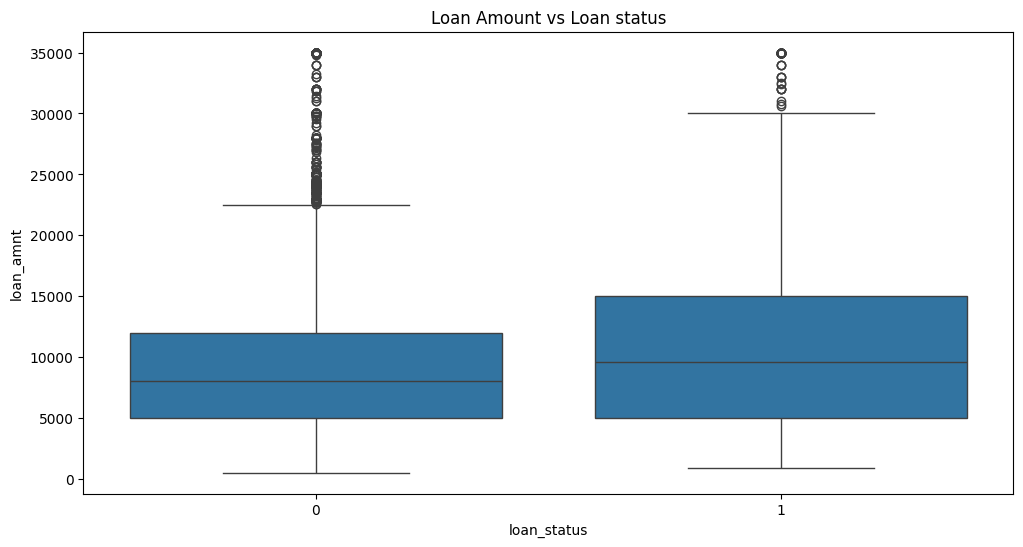

In [30]:
plt.figure(figsize=(12,6))
plt.title("Loan Amount vs Loan status")
sns.boxplot(data=df,x='loan_status',y='loan_amnt')
plt.show()

The boxplot shows that borrowers of loan status 1 have higher loan amounts than borrowers with loan status of 0.The median of loan status 1 is about  9500 dollars  compared 8000 dollars for status 0.Both groups have high outliers, some exceeding 30,000 dollars.

Does loan intent differ between borrowers who defaulted and those who did not?

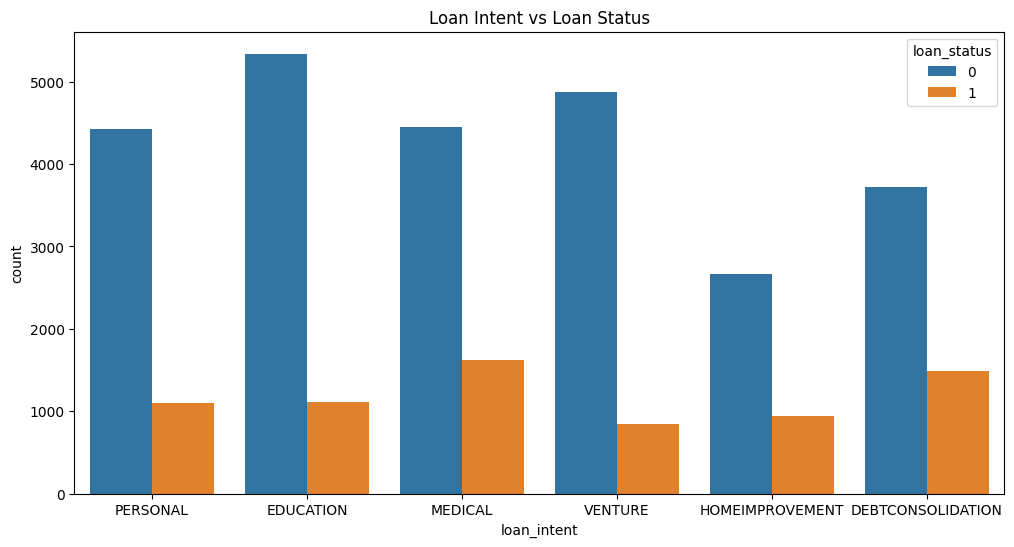

In [31]:
plt.figure(figsize=(12,6))
plt.title("Loan Intent vs Loan Status")
sns.countplot(data=df,x='loan_intent',hue='loan_status')
plt.show()

The countplot shows that borrowers with loan status of 0 have higher number of observations than loan status of 1 across of all loan intents.

Within each loan intent, what proportion of borrowers are in each loan-status category?"

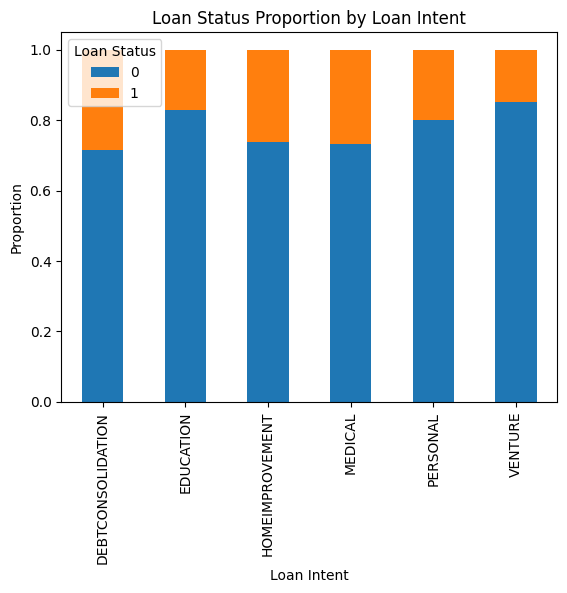

In [32]:
loan_intent_status=pd.crosstab(df['loan_intent'],
                               df['loan_status'],
                               normalize='index')
loan_intent_status.plot(kind='bar',stacked=True)
plt.title('Loan Status Proportion by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Proportion')
plt.legend(title='Loan Status')
plt.show()

Is the proportion of loan defaults different across loan grades?

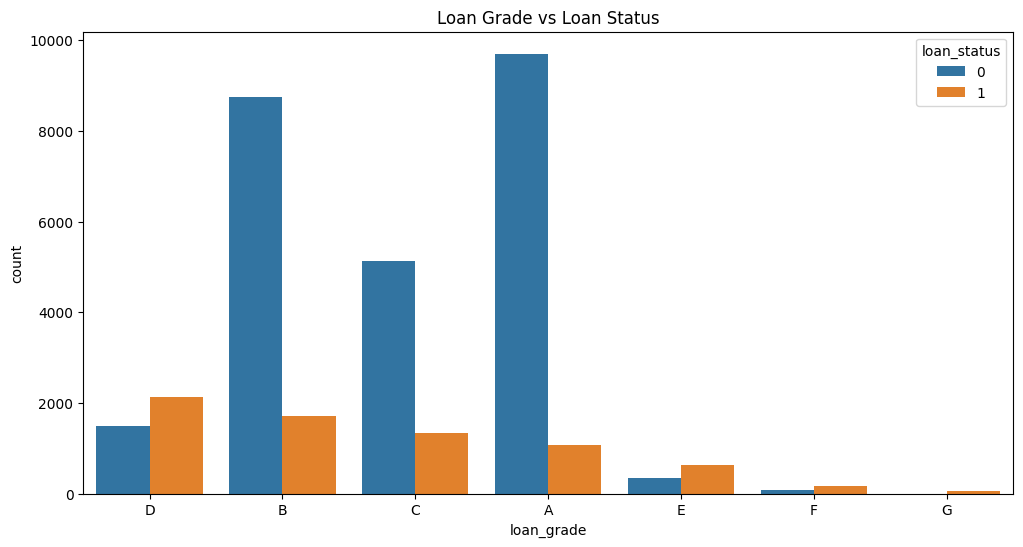

In [33]:
plt.figure(figsize=(12,6))
plt.title("Loan Grade vs Loan Status")
sns.countplot(data=df,x='loan_grade',hue='loan_status')
plt.show()

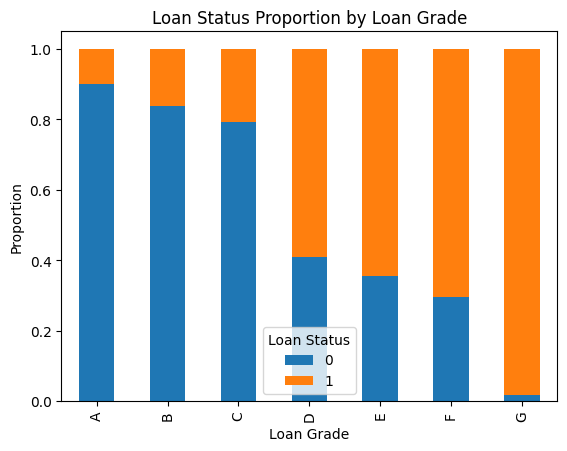

In [34]:
grade_status=pd.crosstab(df['loan_grade'],
                         df['loan_status'],
                         normalize='index'
)
grade_status.plot(kind='bar',stacked=True)
plt.title('Loan Status Proportion by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Proportion')
plt.legend(title='Loan Status')
plt.show()

The proportion of loan defaults differs substantially across loan grades. Higher-grade loans (A–C) have relatively small proportions of defaults, while lower-grade loans (D–G) have much larger proportions of defaults. This suggests that loan grade is strongly associated with loan status in this dataset.

In [37]:
X=df.drop(columns=['loan_status'])
y=df['loan_status']

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [42]:
numerical_features=X_train.select_dtypes(include='number').columns
categorical_features=X_train.select_dtypes(include='object').columns

In [43]:
print("Numerical features: ", numerical_features)
print("Categorical features: ", categorical_features)

Numerical features:  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')
Categorical features:  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [44]:
from sklearn.impute import SimpleImputer
numeric_imputer=SimpleImputer(strategy='median')

In [46]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(handle_unknown='ignore')

In [47]:
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer([('num',numeric_imputer,numerical_features),('cat',encoder,categorical_features)])


In [57]:
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

In [60]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_processed,y_train)
log_pred=log_model.predict(X_test_processed)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


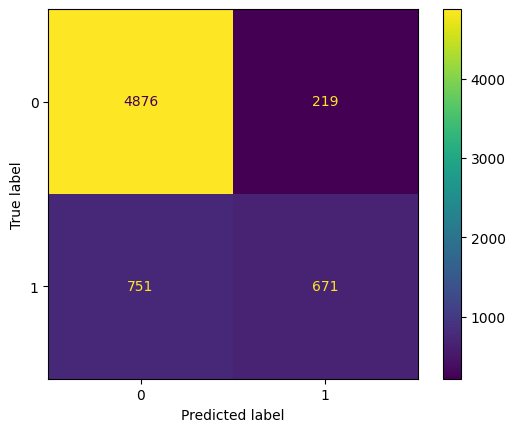

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,log_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
disp.plot()
plt.show()


In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      5095
           1       0.75      0.47      0.58      1422

    accuracy                           0.85      6517
   macro avg       0.81      0.71      0.74      6517
weighted avg       0.84      0.85      0.84      6517



In [65]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed,y_train)
dt_pred=dt_model.predict(X_test_processed)

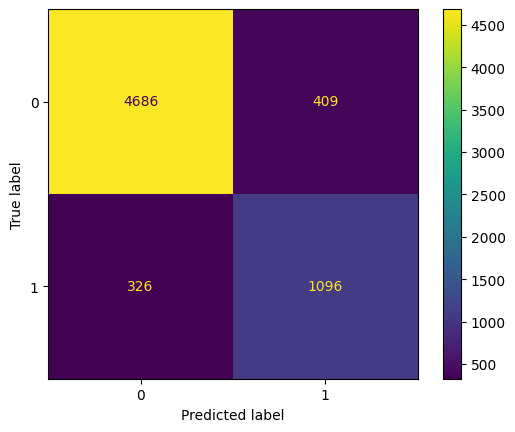

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,dt_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
disp.plot()
plt.show()

In [67]:
from sklearn.metrics import classification_report
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5095
           1       0.73      0.77      0.75      1422

    accuracy                           0.89      6517
   macro avg       0.83      0.85      0.84      6517
weighted avg       0.89      0.89      0.89      6517



The Decision Tree has achived accuracy of 89%.For the default class(1) it achived the precision of 73%, 77% recall and 75% of F1 score. Compared with Logistic Regression, the Decision Tree identified a larger proportion of actual defaults, increasing recall from 47% to 77%, while precision decreased slightly from 75% to 73%.

In [76]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42,n_estimators=200)
rf_model.fit(X_train_processed,y_train)
rf_pred=rf_model.predict(X_test_processed)

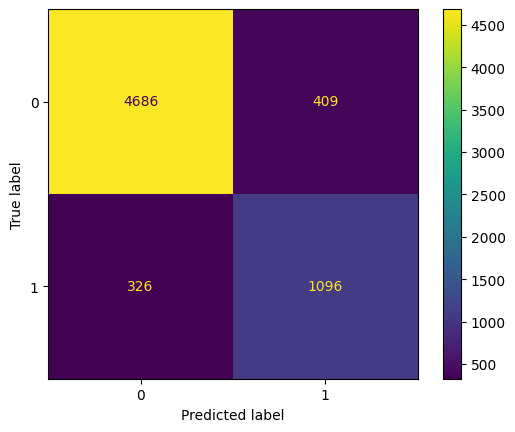

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,rf_pred)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
disp.plot()
plt.show()


In [78]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [82]:
import numpy as np
np.array_equal(dt_pred, rf_pred)

False

In [84]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier()
knn_model.fit(X_train_processed,y_train)
knn_pred=knn_model.predict(X_test_processed)


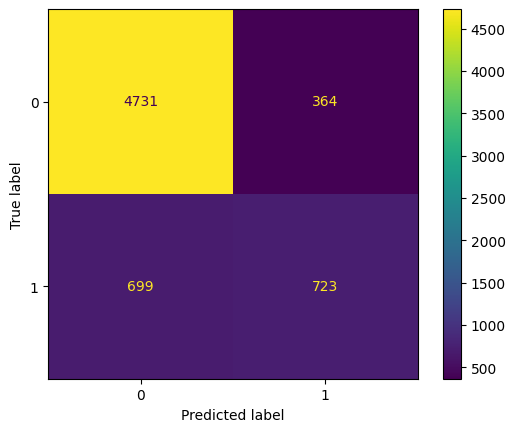

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,knn_pred)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
display.plot()
plt.show()

In [87]:
from sklearn.metrics import classification_report
print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      5095
           1       0.67      0.51      0.58      1422

    accuracy                           0.84      6517
   macro avg       0.77      0.72      0.74      6517
weighted avg       0.83      0.84      0.83      6517



In [89]:
model_results=pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy':[
        0.85,
        0.89,
        0.93,
        0.84
    ],
    'Default Precision':[
        0.75,
        0.73,
        0.97,
        0.67
    ],
    'Default Recall':[
        0.47,
        0.77,
        0.72,
        0.51
    ],
    'Default F1':[
        0.58,
        0.75,
        0.82,
        0.58
    ]
})

In [90]:
model_results

,Model,Accuracy,Default Precision,Default Recall,Default F1
0,Logistic Regression,0.85,0.75,0.47,0.58
1,Decision Tree,0.89,0.73,0.77,0.75
2,Random Forest,0.93,0.97,0.72,0.82
3,KNN,0.84,0.67,0.51,0.58


In [105]:
from sklearn.metrics import roc_auc_score
log_prob=log_model.predict_proba(X_test_processed)[:, 1]
dt_prob=dt_model.predict_proba(X_test_processed)[:,1]
rf_prob=rf_model.predict_proba(X_test_processed)[:,1]
knn_prob=knn_model.predict_proba(X_test_processed)[:,1]

In [106]:
log_auc=roc_auc_score(y_test,log_prob)
dt_auc=roc_auc_score(y_test,dt_prob)
rf_auc=roc_auc_score(y_test,rf_prob)
knn_auc=roc_auc_score(y_test,knn_prob)

In [107]:
print("Logistic Regression AUC:", log_auc)
print("Decision Tree AUC:", dt_auc)
print("Random Forest AUC:", rf_auc)
print("KNN AUC:", knn_auc)

Logistic Regression AUC: 0.8456754850526356
Decision Tree AUC: 0.8452353248889939
Random Forest AUC: 0.9312894663834402
KNN AUC: 0.8124219988985644


In [108]:
model_results['AUC'] = [
    log_auc,
    dt_auc,
    rf_auc,
    knn_auc
]

model_results

,Model,Accuracy,Default Precision,Default Recall,Default F1,AUC
0,Logistic Regression,0.85,0.75,0.47,0.58,0.85
1,Decision Tree,0.89,0.73,0.77,0.75,0.85
2,Random Forest,0.93,0.97,0.72,0.82,0.93
3,KNN,0.84,0.67,0.51,0.58,0.81


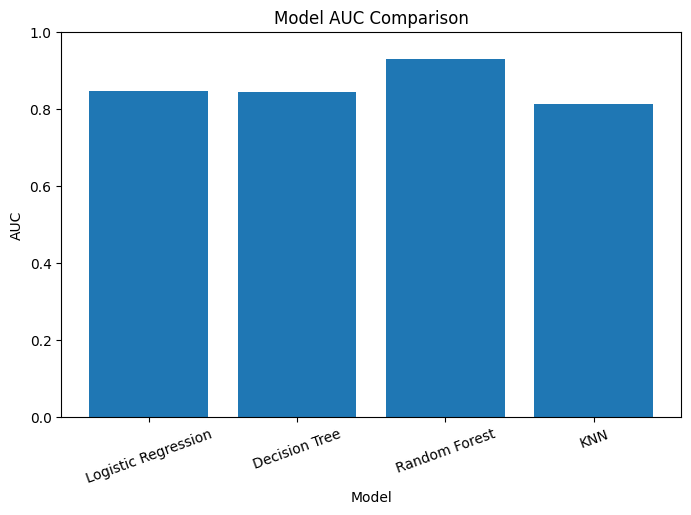

In [109]:
plt.figure(figsize=(8,5))
plt.bar(model_results['Model'],model_results['AUC'])
plt.title('Model AUC Comparison')
plt.xlabel('Model')
plt.ylabel('AUC')
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.show()

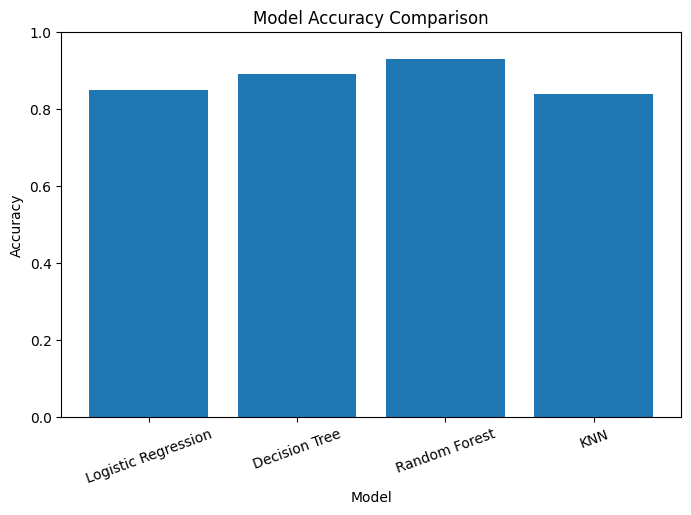

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(model_results['Model'], model_results['Accuracy'])

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.show()

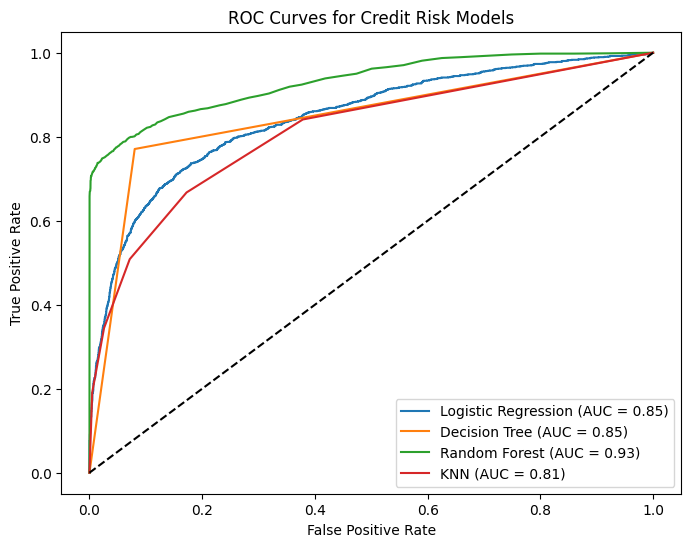

In [112]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {knn_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Credit Risk Models')
plt.legend()
plt.show()


## Conclusion
This project analyzed a credit risk dataset to identify patterns associated with loan default and to build machine learning prediction models for loan status.Exploratory analysis showed that the target variable loan status was imbalanced with more borrrowers having status of 0 than 1.The analysis also showed differences across loan grades,higher loan grades having higher proportions of default.Four machine learning models were developed and evaluated:Logistic Regression,Decision Tree Classifier,Random Forest Classifier and Kneighbors Classifier.The prediction models were evaluated and compared using precision,accuracy,recall,F1-score and AUC.The Random Forest had an accuracy of 0.93 and AUC of 0.93.